In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
import os

os.listdir('/content')

['.config', 'drive', 'sample_data']

In [26]:
# Cell 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For text processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

# For visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab') # Added to download the missing resource

print("Libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Libraries imported successfully!


In [27]:
df = pd.read_csv("/content/toxic_comments_dataset.csv")

In [6]:
from google.colab import files

# Run this cell to open a file selection dialog
# uploaded = files.upload()

# # To see the uploaded file(s) and their content (optional)
# for fn in uploaded.keys():
#   print('User uploaded file "{name}" with length {length} bytes'.format(
#       name=fn, length=len(uploaded[fn])))


In [28]:
# Cell 2: Load the dataset
# Read the CSV file
df = pd.read_csv("/content/toxic_comments_dataset.csv")

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (30000, 15)

First 5 rows:


,Comment_ID,Comment_Text,Toxicity_Label,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count,Platform,Topic,Moderation_Priority,Language
0,COM000001,The message targets a group unfairly and viola...,Identity_Attack,0,1,0,0,1,0.818,66,10,Community Chat,Sports,High,English
1,COM000002,Thank you for sharing this perspective with th...,Clean,1,0,0,0,0,0.069,58,9,News Comments,Entertainment,High,English
2,COM000003,That response is aggressive and not helpful.,Toxic,0,1,0,0,0,0.622,44,7,Social Media,Politics,Low,English
3,COM000004,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.010,61,9,Social Media,Entertainment,Low,English
4,COM000005,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.140,52,8,Blog,Sports,Low,English


In [8]:
# Cell 3: Basic dataset information
print("=== Dataset Information ===")
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMemory Usage:")
print(df.info(memory_usage='deep'))

print("\nBasic Statistics:")
df.describe()

=== Dataset Information ===

Column Names:
['Comment_ID', 'Comment_Text', 'Toxicity_Label', 'Clean', 'Toxic', 'Severe_Toxic', 'Threat', 'Identity_Attack', 'Toxicity_Score', 'Comment_Length', 'Word_Count', 'Platform', 'Topic', 'Moderation_Priority', 'Language']

Data Types:
Comment_ID              object
Comment_Text            object
Toxicity_Label          object
Clean                    int64
Toxic                    int64
Severe_Toxic             int64
Threat                   int64
Identity_Attack          int64
Toxicity_Score         float64
Comment_Length           int64
Word_Count               int64
Platform                object
Topic                   object
Moderation_Priority     object
Language                object
dtype: object

Memory Usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Comment_ID        

,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.619300,0.380700,0.060033,0.048633,0.048933,0.324542,56.357633,8.340633
std,0.485567,0.485567,0.237553,0.215104,0.215732,0.302914,6.962596,0.972094
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,39.000000,6.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.079000,52.000000,8.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.161000,58.000000,8.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.624000,61.000000,9.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.950000,71.000000,11.000000


In [9]:
# Cell 4: Check for missing values
print("=== Missing Values ===")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percentage': missing_percentage
})
print(missing_df[missing_df['Missing_Count'] > 0])

=== Missing Values ===
Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []


In [10]:
# Cell 5: Check for duplicates
print("=== Duplicate Check ===")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("Duplicate rows found. We'll handle them in preprocessing.")

=== Duplicate Check ===
Number of duplicate rows: 0


In [11]:
# Cell 6: Data types and unique values analysis
print("=== Column Analysis ===")
for col in df.columns:
    print(f"\nColumn: {col}")
    print(f"  Data Type: {df[col].dtype}")
    print(f"  Unique Values: {df[col].nunique()}")
    if df[col].dtype == 'object' and df[col].nunique() < 20:
        print(f"  Value Counts:\n{df[col].value_counts()}")

=== Column Analysis ===

Column: Comment_ID
  Data Type: object
  Unique Values: 30000

Column: Comment_Text
  Data Type: object
  Unique Values: 17
  Value Counts:
Comment_Text
This article provides useful information and clear examples.               4685
Thank you for sharing this perspective with the community.                 4681
I respectfully disagree but I understand your point.                       4659
I appreciate your explanation and the discussion was helpful.              4554
The tone of this message is toxic and inappropriate.                       1721
That response is aggressive and not helpful.                               1703
Your message is unnecessarily hostile and offensive.                       1646
This comment is rude and disrespectful.                                    1623
This message contains severe abusive language and should be removed.        620
The comment is extremely hostile and violates community standards.          593
This reply includes in

=== Toxicity Label Distribution ===
Toxicity_Label
Clean              18579
Toxic               6693
Severe_Toxic        1801
Identity_Attack     1468
Threat              1459
Name: count, dtype: int64


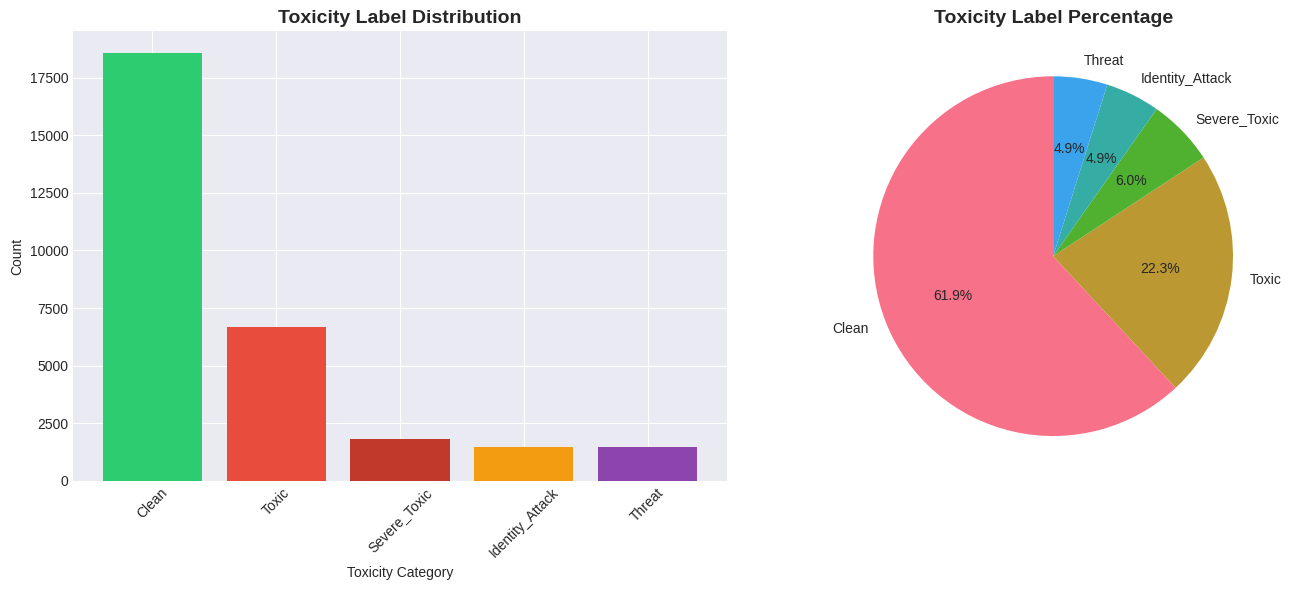


Class Imbalance Ratio:
Clean: 61.93%
Toxic: 22.31%
Severe_Toxic: 6.00%
Identity_Attack: 4.89%
Threat: 4.86%


In [12]:
# Cell 7: Target variable distribution
print("=== Toxicity Label Distribution ===")
toxicity_counts = df['Toxicity_Label'].value_counts()
print(toxicity_counts)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot
axes[0].bar(toxicity_counts.index, toxicity_counts.values,
            color=['#2ecc71', '#e74c3c', '#c0392b', '#f39c12', '#8e44ad'])
axes[0].set_title('Toxicity Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Toxicity Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(toxicity_counts.values, labels=toxicity_counts.index,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Toxicity Label Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Class imbalance check
print("\nClass Imbalance Ratio:")
for label, count in toxicity_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{label}: {percentage:.2f}%")

=== Binary Label Analysis ===
Clean: 18579 (61.93%)
Toxic: 11421 (38.07%)
Severe_Toxic: 1801 (6.00%)
Threat: 1459 (4.86%)
Identity_Attack: 1468 (4.89%)


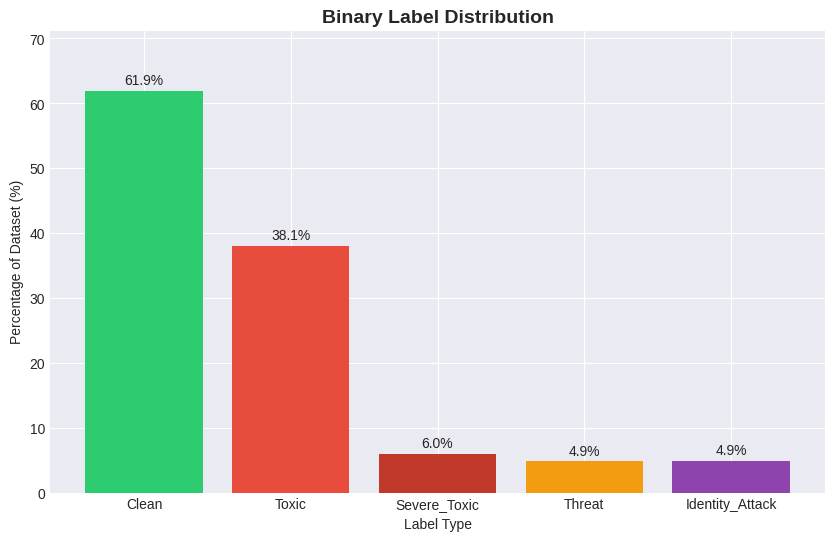

In [13]:
# Cell 8: Binary label analysis
print("=== Binary Label Analysis ===")
binary_columns = ['Clean', 'Toxic', 'Severe_Toxic', 'Threat', 'Identity_Attack']

binary_stats = {}
for col in binary_columns:
    if col in df.columns:
        positive_count = df[col].sum()
        percentage = (positive_count / len(df)) * 100
        binary_stats[col] = {'Count': positive_count, 'Percentage': percentage}
        print(f"{col}: {positive_count} ({percentage:.2f}%)")

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71', '#e74c3c', '#c0392b', '#f39c12', '#8e44ad']

ax.bar(binary_stats.keys(), [v['Percentage'] for v in binary_stats.values()], color=colors)
ax.set_title('Binary Label Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Label Type')
ax.set_ylabel('Percentage of Dataset (%)')
ax.set_ylim(0, max([v['Percentage'] for v in binary_stats.values()]) * 1.15)

# Add percentage labels on bars
for i, (key, value) in enumerate(binary_stats.items()):
    ax.text(i, value['Percentage'] + 0.5, f"{value['Percentage']:.1f}%",
            ha='center', va='bottom')

plt.show()

=== Comment Text Statistics ===
         word_count    char_count  avg_word_length
count  30000.000000  30000.000000     30000.000000
mean       8.340633     56.357633         6.767231
std        0.972094      6.962596         0.495295
min        6.000000     39.000000         5.777778
25%        8.000000     52.000000         6.444444
50%        8.000000     58.000000         6.500000
75%        9.000000     61.000000         7.333333
max       11.000000     71.000000         7.625000


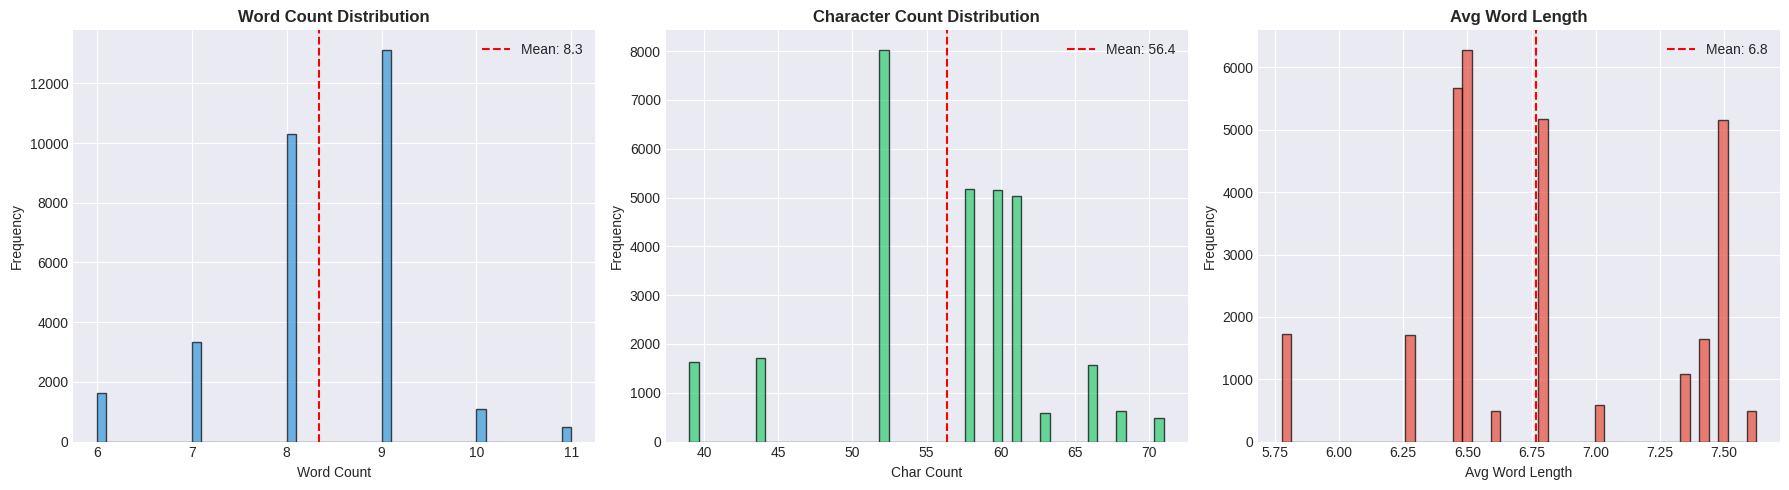

In [15]:
# Cell 9: Comment length analysis
def get_text_stats(text):
    """Calculate various statistics for a text"""
    words = str(text).split()
    chars = len(str(text))
    return {
        'word_count': len(words),
        'char_count': chars,
        'avg_word_length': chars / len(words) if len(words) > 0 else 0
    }

# Apply to comments
text_stats = df['Comment_Text'].apply(get_text_stats)
df_stats = pd.DataFrame(text_stats.tolist())

print("=== Comment Text Statistics ===")
print(df_stats.describe())

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

stats = ['word_count', 'char_count', 'avg_word_length']
titles = ['Word Count Distribution', 'Character Count Distribution', 'Avg Word Length']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (stat, title, color) in enumerate(zip(stats, titles, colors)):
    axes[i].hist(df_stats[stat], bins=50, color=color, alpha=0.7, edgecolor='black')
    axes[i].axvline(df_stats[stat].mean(), color='red', linestyle='--',
                    label=f'Mean: {df_stats[stat].mean():.1f}')
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(stat.replace('_', ' ').title())
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()

=== Text Length by Toxicity Category ===

Identity_Attack:
  Mean: 9.7
  Median: 10.0
  Std: 1.2
  Min: 8.0
  Max: 11.0

Clean:
  Mean: 8.5
  Median: 8.0
  Std: 0.5
  Min: 8.0
  Max: 9.0

Toxic:
  Mean: 7.3
  Median: 7.0
  Std: 1.1
  Min: 6.0
  Max: 9.0

Threat:
  Mean: 8.7
  Median: 9.0
  Std: 0.5
  Min: 8.0
  Max: 9.0

Severe_Toxic:
  Mean: 9.3
  Median: 9.0
  Std: 0.5
  Min: 9.0
  Max: 10.0


<Figure size 1200x600 with 0 Axes>

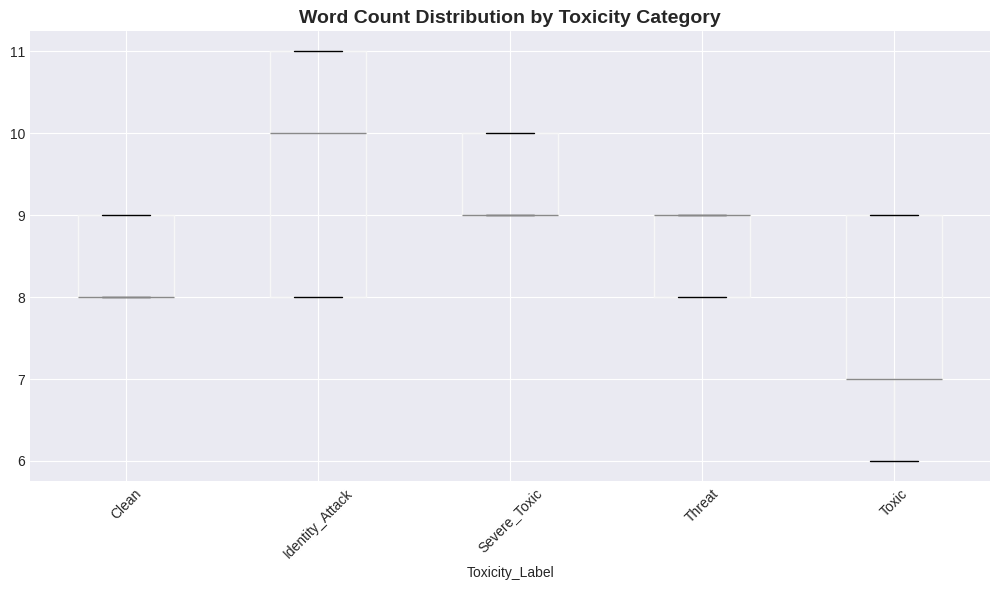

In [16]:
# Cell 10: Length analysis by toxicity category
print("=== Text Length by Toxicity Category ===")
df['Word_Count'] = df_stats['word_count']

for label in df['Toxicity_Label'].unique():
    category_data = df[df['Toxicity_Label'] == label]
    stats = category_data['Word_Count'].describe()
    print(f"\n{label}:")
    print(f"  Mean: {stats['mean']:.1f}")
    print(f"  Median: {stats['50%']:.1f}")
    print(f"  Std: {stats['std']:.1f}")
    print(f"  Min: {stats['min']:.1f}")
    print(f"  Max: {stats['max']:.1f}")

# Boxplot visualization
plt.figure(figsize=(12, 6))
df.boxplot(column='Word_Count', by='Toxicity_Label', figsize=(12, 6))
plt.title('Word Count Distribution by Toxicity Category', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xticks(rotation=45)
plt.show()

=== Platform Analysis ===
Platform
Community Chat    6078
News Comments     6058
Blog              5971
Social Media      5967
Forum             5926
Name: count, dtype: int64


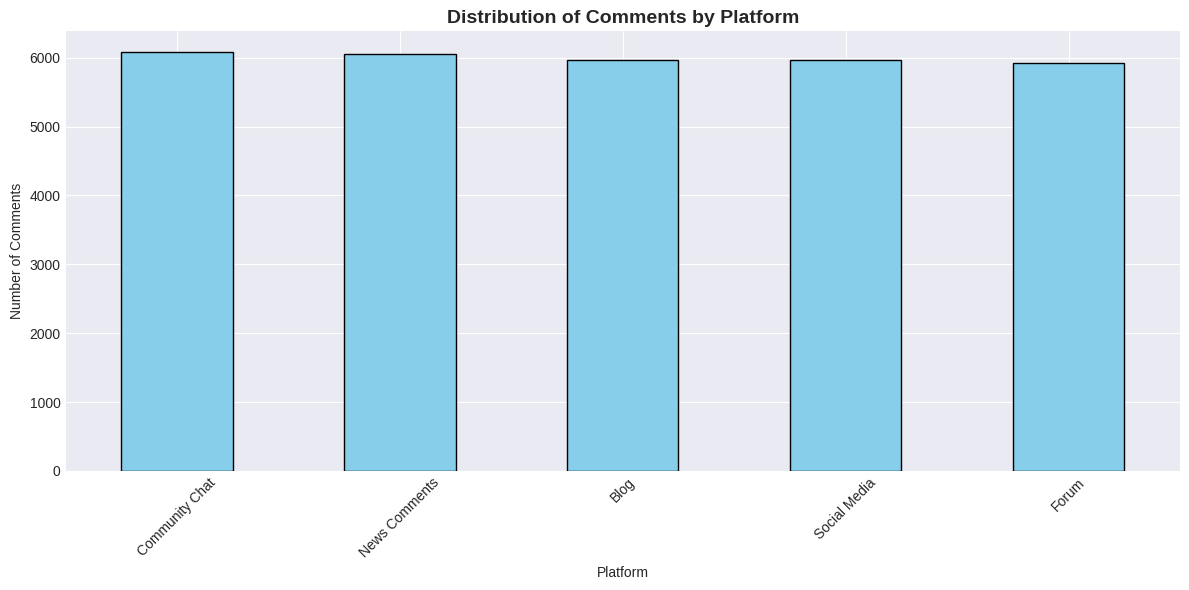

In [17]:
# Cell 11: Platform analysis
if 'Platform' in df.columns:
    print("=== Platform Analysis ===")
    platform_counts = df['Platform'].value_counts()
    print(platform_counts)

    plt.figure(figsize=(12, 6))
    platform_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Distribution of Comments by Platform', fontsize=14, fontweight='bold')
    plt.xlabel('Platform')
    plt.ylabel('Number of Comments')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

=== Topic Analysis ===
Topic
Technology       5105
Education        5052
Gaming           5021
Politics         4987
Sports           4964
Entertainment    4871
Name: count, dtype: int64


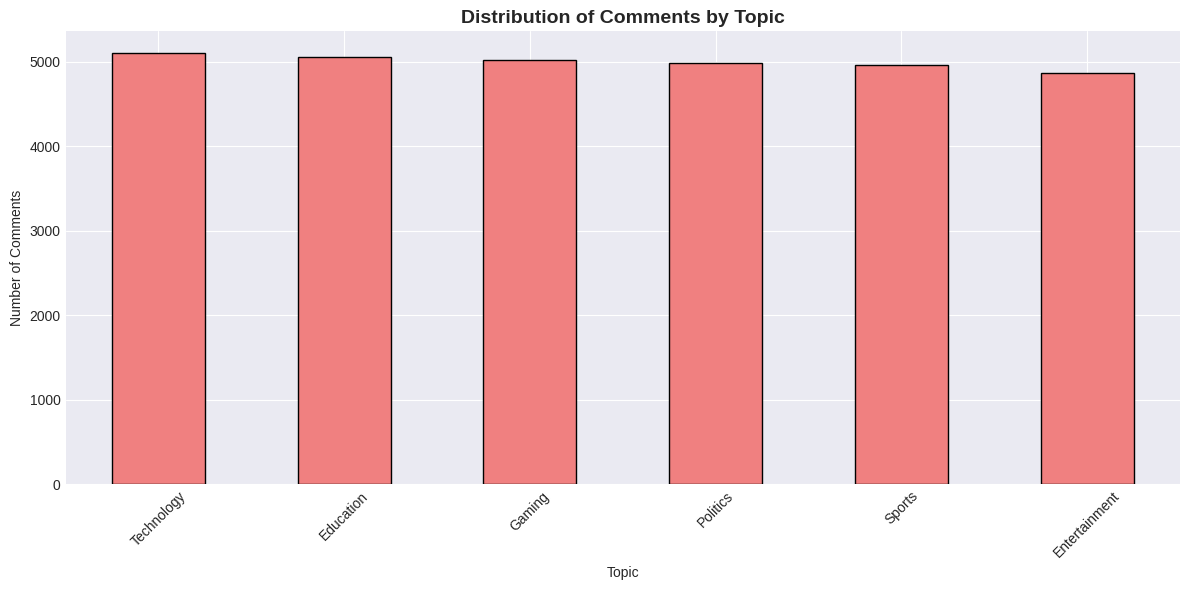

In [18]:
# Cell 12: Topic analysis
if 'Topic' in df.columns:
    print("=== Topic Analysis ===")
    topic_counts = df['Topic'].value_counts()
    print(topic_counts)

    plt.figure(figsize=(12, 6))
    topic_counts.plot(kind='bar', color='lightcoral', edgecolor='black')
    plt.title('Distribution of Comments by Topic', fontsize=14, fontweight='bold')
    plt.xlabel('Topic')
    plt.ylabel('Number of Comments')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

=== Toxicity Distribution by Platform ===
Toxicity_Label      Clean  Identity_Attack  Severe_Toxic    Threat      Toxic
Platform                                                                     
Blog            62.150394         4.521856      5.710936  5.041032  22.575783
Community Chat  62.207963         4.837117      5.955907  4.738401  22.260612
Forum           62.065474         5.163685      6.378670  4.792440  21.599730
News Comments   61.654011         4.803566      5.843513  4.820073  22.878838
Social Media    61.571979         5.144964      6.133736  4.927099  22.222222


<Figure size 1400x800 with 0 Axes>

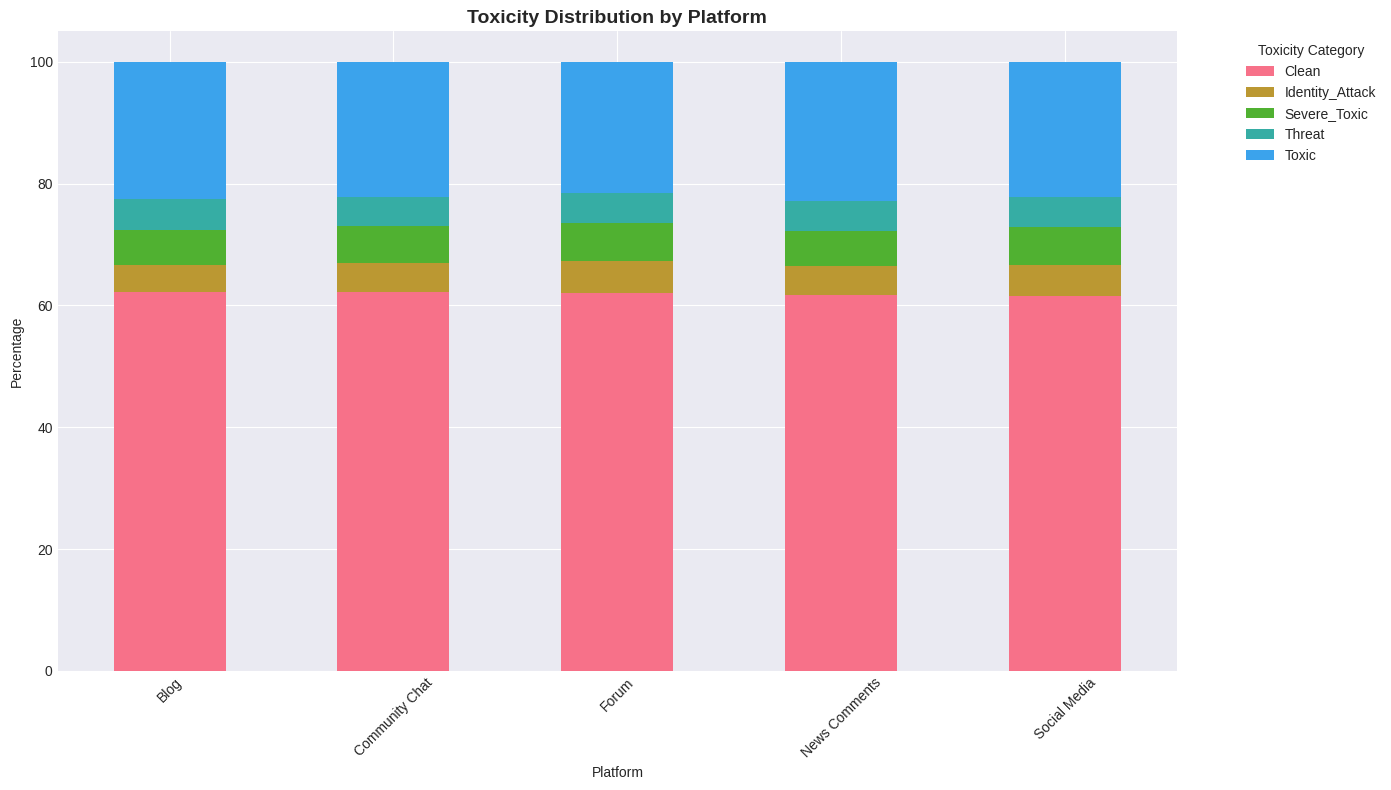

In [19]:
# Cell 13: Cross-analysis - Toxicity by Platform
if 'Platform' in df.columns and 'Toxicity_Label' in df.columns:
    print("=== Toxicity Distribution by Platform ===")
    cross_tab = pd.crosstab(df['Platform'], df['Toxicity_Label'], normalize='index') * 100
    print(cross_tab)

    plt.figure(figsize=(14, 8))
    cross_tab.plot(kind='bar', stacked=True, figsize=(14, 8))
    plt.title('Toxicity Distribution by Platform', fontsize=14, fontweight='bold')
    plt.xlabel('Platform')
    plt.ylabel('Percentage')
    plt.legend(title='Toxicity Category', bbox_to_anchor=(1.05, 1))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

=== Correlation Matrix ===


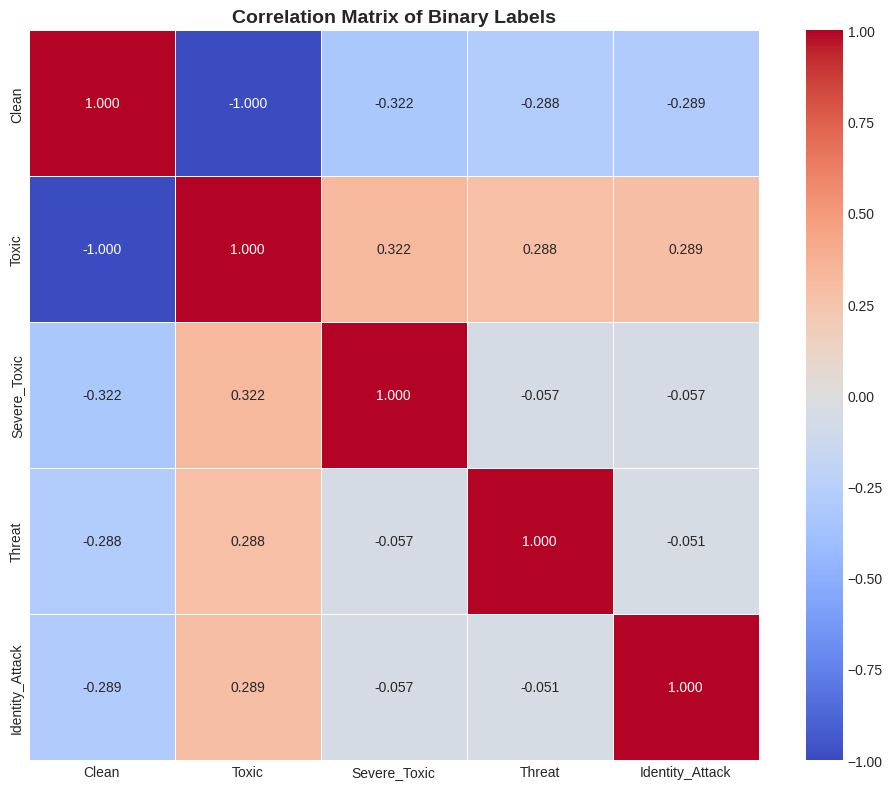

In [20]:
# Cell 14: Correlation matrix for binary labels
if all(col in df.columns for col in binary_columns):
    print("=== Correlation Matrix ===")
    corr_matrix = df[binary_columns].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, fmt='.3f')
    plt.title('Correlation Matrix of Binary Labels', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [22]:
# Cell 15: Text Preprocessing Functions
def clean_text(text):
    """Clean and preprocess text"""
    if pd.isna(text):
        return ""

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags but keep the word
    text = re.sub(r'#(\w+)', r'\1', text)

    # Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def tokenize_and_lemmatize(text):
    """Tokenize and lemmatize text"""
    # Tokenize
    tokens = nltk.word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return tokens

print("Text preprocessing functions defined!")

Text preprocessing functions defined!


In [29]:
# Cell 16: Apply text preprocessing
print("=== Preprocessing Comments ===")

# Create a copy of the dataset
df_processed = df.copy()

# Apply cleaning
print("Cleaning text...")
df_processed['Cleaned_Comment'] = df_processed['Comment_Text'].apply(clean_text)

# Tokenize and lemmatize
print("Tokenizing and lemmatizing...")
df_processed['Tokens'] = df_processed['Cleaned_Comment'].apply(tokenize_and_lemmatize)

# Create cleaned text (joined tokens)
df_processed['Processed_Comment'] = df_processed['Tokens'].apply(lambda x: ' '.join(x))

print("Text preprocessing complete!")
print(f"Sample: {df_processed['Processed_Comment'][0][:100]}...")

=== Preprocessing Comments ===
Cleaning text...
Tokenizing and lemmatizing...
Text preprocessing complete!
Sample: message target group unfairly violates community rule...


In [32]:
# Cell 17: Compare before and after preprocessing
print("=== Before and After Comparison ===")
sample_idx = 0
print(f"Original: {df_processed['Comment_Text'][sample_idx][:200]}")
print(f"Cleaned: {df_processed['Cleaned_Comment'][sample_idx][:200]}")
print(f"Processed: {df_processed['Processed_Comment'][sample_idx][:200]}")

=== Before and After Comparison ===
Original: The message targets a group unfairly and violates community rules.
Cleaned: the message targets a group unfairly and violates community rules
Processed: message target group unfairly violates community rule


=== Most Common Words ===


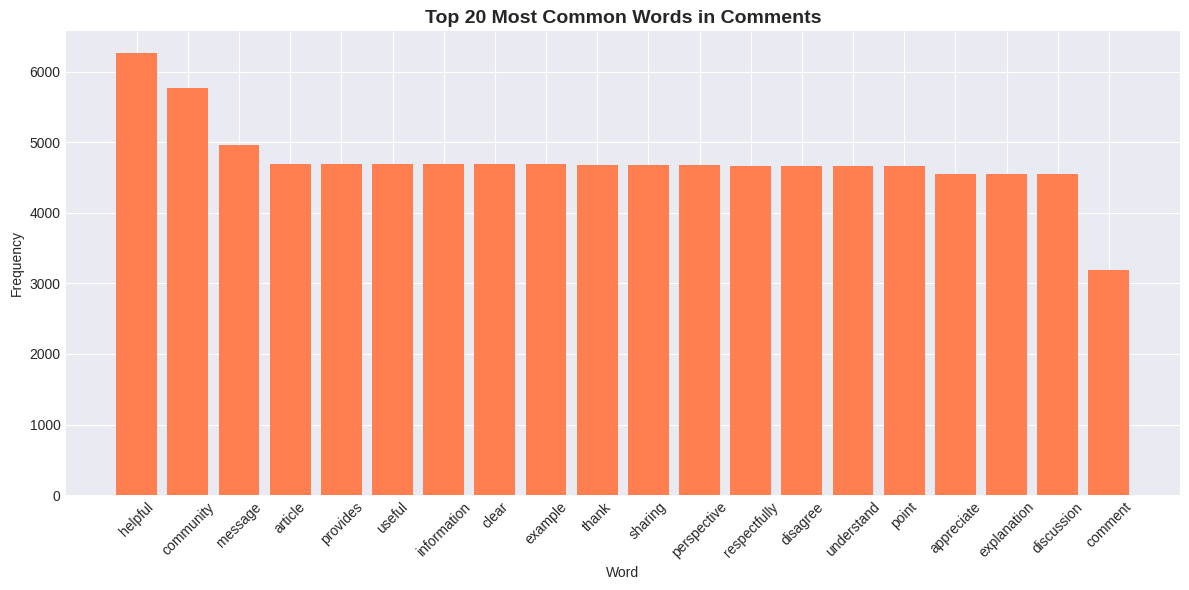

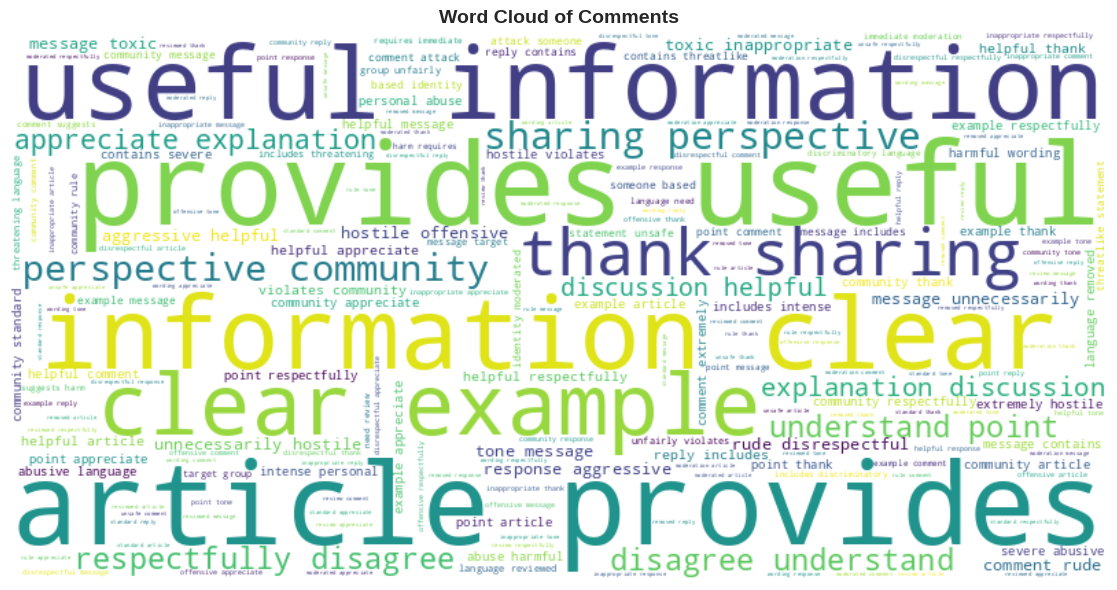

In [33]:
# Cell 18: Most common words analysis
print("=== Most Common Words ===")
all_tokens = [token for tokens in df_processed['Tokens'] for token in tokens]
word_freq = Counter(all_tokens)

# Top 20 words
top_words = word_freq.most_common(20)
top_words_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])

plt.figure(figsize=(12, 6))
plt.bar(top_words_df['Word'], top_words_df['Frequency'], color='coral')
plt.title('Top 20 Most Common Words in Comments', fontsize=14, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Word cloud (optional - requires wordcloud package)
try:
    from wordcloud import WordCloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_tokens))
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Comments', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
except ImportError:
    print("WordCloud package not installed. Skipping word cloud generation.")
    print("To install: pip install wordcloud")

In [35]:
# Cell 19: Additional Features
print("=== Feature Engineering ===")

# Add text length features
df_processed['Comment_Length'] = df_processed['Comment_Text'].str.len()
df_processed['Processed_Length'] = df_processed['Cleaned_Comment'].str.len()
df_processed['Token_Count'] = df_processed['Tokens'].str.len()

# Add punctuation and special character counts
df_processed['Exclamation_Count'] = df_processed['Comment_Text'].str.count('!')
df_processed['Question_Count'] = df_processed['Comment_Text'].str.count('\?')
df_processed['Upper_Count'] = df_processed['Comment_Text'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))

# Add sentiment features (if needed - using TextBlob)
try:
    from textblob import TextBlob
    df_processed['Sentiment_Polarity'] = df_processed['Comment_Text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
    df_processed['Sentiment_Subjectivity'] = df_processed['Comment_Text'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)
    print("Sentiment features added!")
except ImportError:
    print("TextBlob not installed. Skipping sentiment features.")
    print("To install: pip install textblob")

print("\nNew features created:")
new_features = [col for col in df_processed.columns if col not in df.columns]
print(f"Added features: {new_features}")

=== Feature Engineering ===
Sentiment features added!

New features created:
Added features: ['Cleaned_Comment', 'Tokens', 'Processed_Comment', 'Processed_Length', 'Token_Count', 'Exclamation_Count', 'Question_Count', 'Upper_Count', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


In [36]:
# Cell 20: Encode target variable
from sklearn.preprocessing import LabelEncoder

print("=== Encoding Labels ===")
# Encode Toxicity_Label
label_encoder = LabelEncoder()
df_processed['Toxicity_Label_Encoded'] = label_encoder.fit_transform(df_processed['Toxicity_Label'])

# Display mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Encoding Mapping:")
for label, code in label_mapping.items():
    print(f"  {label} -> {code}")

=== Encoding Labels ===
Label Encoding Mapping:
  Clean -> 0
  Identity_Attack -> 1
  Severe_Toxic -> 2
  Threat -> 3
  Toxic -> 4


In [37]:
# Cell 21: Prepare features for ML
print("=== Preparing ML Features ===")

# Select features for ML
ml_features = []

# Add numeric features
numeric_cols = ['Comment_Length', 'Processed_Length', 'Token_Count',
                'Exclamation_Count', 'Question_Count', 'Upper_Count']

if 'Sentiment_Polarity' in df_processed.columns:
    numeric_cols.extend(['Sentiment_Polarity', 'Sentiment_Subjectivity'])

# Add binary labels as features (optional)
binary_features = [col for col in binary_columns if col != 'Clean']

# For multi-class classification, we'll use:
# - Numeric features
# - Binary labels as additional features
# - Processed text for TF-IDF/Word Embeddings

print("Numeric features:", numeric_cols)
print("Binary features:", binary_features)

# Create feature matrix (numeric + binary)
X_numeric = df_processed[numeric_cols + binary_features].copy()
y = df_processed['Toxicity_Label_Encoded']

print(f"\nFeature matrix shape: {X_numeric.shape}")
print(f"Target shape: {y.shape}")

=== Preparing ML Features ===
Numeric features: ['Comment_Length', 'Processed_Length', 'Token_Count', 'Exclamation_Count', 'Question_Count', 'Upper_Count', 'Sentiment_Polarity', 'Sentiment_Subjectivity']
Binary features: ['Toxic', 'Severe_Toxic', 'Threat', 'Identity_Attack']

Feature matrix shape: (30000, 12)
Target shape: (30000,)


In [38]:
# Cell 22: Create TF-IDF features
from sklearn.feature_extraction.text import TfidfVectorizer

print("=== Creating TF-IDF Features ===")

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_tfidf = tfidf_vectorizer.fit_transform(df_processed['Processed_Comment'])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Number of features: {X_tfidf.shape[1]}")

=== Creating TF-IDF Features ===
TF-IDF matrix shape: (30000, 132)
Number of features: 132


In [39]:
# Cell 23: Split data into train and test sets
from sklearn.model_selection import train_test_split

print("=== Train-Test Split ===")

# Combine features (numeric + binary)
X_numeric_matrix = X_numeric.values

# Split the data
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

X_train_numeric, X_test_numeric, y_train_numeric, y_test_numeric = train_test_split(
    X_numeric_matrix, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set (TF-IDF): {X_train_tfidf.shape}")
print(f"Test set (TF-IDF): {X_test_tfidf.shape}")
print(f"Training set (Numeric): {X_train_numeric.shape}")
print(f"Test set (Numeric): {X_test_numeric.shape}")
print(f"\nTraining target distribution:\n{pd.Series(y_train).value_counts()}")
print(f"\nTest target distribution:\n{pd.Series(y_test).value_counts()}")

=== Train-Test Split ===
Training set (TF-IDF): (24000, 132)
Test set (TF-IDF): (6000, 132)
Training set (Numeric): (24000, 12)
Test set (Numeric): (6000, 12)

Training target distribution:
Toxicity_Label_Encoded
0    14863
4     5354
2     1441
1     1175
3     1167
Name: count, dtype: int64

Test target distribution:
Toxicity_Label_Encoded
0    3716
4    1339
2     360
1     293
3     292
Name: count, dtype: int64


=== Baseline Model Training (TF-IDF) ===
Accuracy: 1.0

Classification Report:
                 precision    recall  f1-score   support

          Clean       1.00      1.00      1.00      3716
Identity_Attack       1.00      1.00      1.00       293
   Severe_Toxic       1.00      1.00      1.00       360
         Threat       1.00      1.00      1.00       292
          Toxic       1.00      1.00      1.00      1339

       accuracy                           1.00      6000
      macro avg       1.00      1.00      1.00      6000
   weighted avg       1.00      1.00      1.00      6000



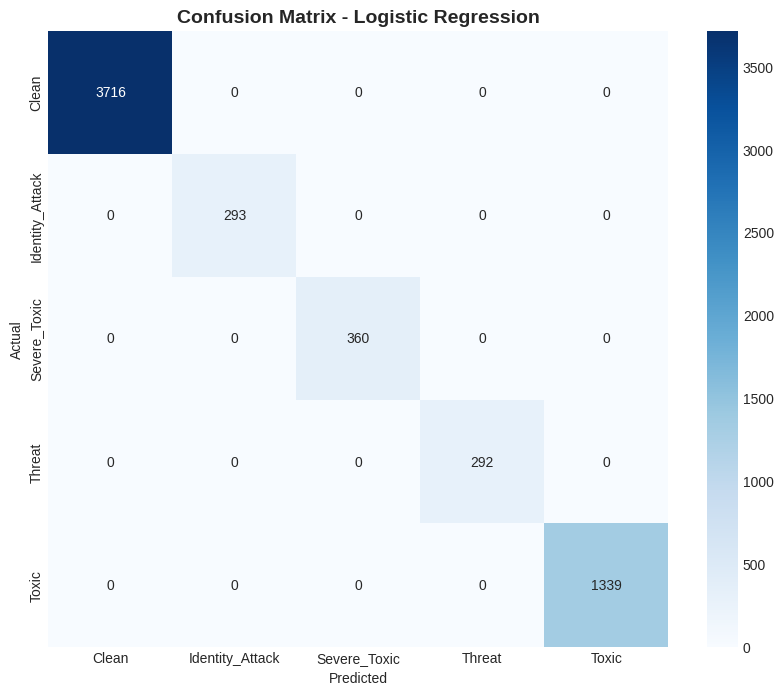

In [40]:
# Cell 24: Train a baseline model (Logistic Regression)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("=== Baseline Model Training (TF-IDF) ===")

# Logistic Regression
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_tfidf, y_train)

# Predictions
y_pred = clf.predict(X_test_tfidf)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [41]:
# Cell 25: Train model with numeric features
print("=== Model Training (Numeric Features) ===")

# Logistic Regression with numeric features
clf_numeric = LogisticRegression(max_iter=1000, random_state=42)
clf_numeric.fit(X_train_numeric, y_train_numeric)

# Predictions
y_pred_numeric = clf_numeric.predict(X_test_numeric)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_numeric))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_numeric, target_names=label_encoder.classes_))

=== Model Training (Numeric Features) ===
Accuracy: 1.0

Classification Report:
                 precision    recall  f1-score   support

          Clean       1.00      1.00      1.00      3716
Identity_Attack       1.00      1.00      1.00       293
   Severe_Toxic       1.00      1.00      1.00       360
         Threat       1.00      1.00      1.00       292
          Toxic       1.00      1.00      1.00      1339

       accuracy                           1.00      6000
      macro avg       1.00      1.00      1.00      6000
   weighted avg       1.00      1.00      1.00      6000



In [42]:
# Cell 26: Save preprocessed data
print("=== Saving Preprocessed Data ===")

# Save processed dataset
df_processed.to_csv('toxic_comments_processed.csv', index=False)
print("✓ Processed dataset saved to 'toxic_comments_processed.csv'")

# Save TF-IDF vectorizer
import joblib
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
print("✓ TF-IDF vectorizer saved to 'tfidf_vectorizer.pkl'")

joblib.dump(label_encoder, 'label_encoder.pkl')
print("✓ Label encoder saved to 'label_encoder.pkl'")

# Save the model
joblib.dump(clf, 'toxicity_model.pkl')
print("✓ Model saved to 'toxicity_model.pkl'")

print("\nAll files saved successfully!")

=== Saving Preprocessed Data ===
✓ Processed dataset saved to 'toxic_comments_processed.csv'
✓ TF-IDF vectorizer saved to 'tfidf_vectorizer.pkl'
✓ Label encoder saved to 'label_encoder.pkl'
✓ Model saved to 'toxicity_model.pkl'

All files saved successfully!


In [47]:
# Cell 27: EDA Summary Report
print("="*80)
print("TOXIC COMMENTS DATASET - EDA & PREPROCESSING SUMMARY")
print("="*80)

print(f"\nDataset Name: Toxic Comments Dataset 2026")
print(f"Total Records: {len(df)}")
print(f"Total Features: {len(df.columns)}")

print(f"\nTarget Distribution:")
for label, count in toxicity_counts.items():
    print(f"  {label}: {count} ({count/len(df)*100:.2f}%)")

print(f"\nClass Imbalance: {'Significant' if max(toxicity_counts) / min(toxicity_counts) > 3 else 'Moderate'}")
print(f"Imbalance Ratio: {max(toxicity_counts) / min(toxicity_counts):.2f}")

print(f"\nText Statistics:")
print(f"  Average Comment Length: {df_stats['char_count'].mean():.1f} characters")
print(f"  Average Word Count: {df_stats['word_count'].mean():.1f} words")
print(f"  Average Word Length: {df_stats['avg_word_length'].mean():.1f} characters")

print(f"\nPreprocessing Summary:")
print(f"  - Removed URLs, mentions, special characters")
print(f"  - Applied tokenization and lemmatization")
print(f"  - Added {len(new_features)} engineered features")
print(f"  - Encoded target labels")

print(f"\nModeling Ready:")
print(f"  - TF-IDF features: {X_tfidf.shape[1]} features")
print(f"  - Numeric features: {X_numeric.shape[1]} features")
print(f"  - Train/Test split: 80/20")

print("\n✓ EDA and Preprocessing Complete!")
print("="*80)

TOXIC COMMENTS DATASET - EDA & PREPROCESSING SUMMARY

Dataset Name: Toxic Comments Dataset 2026
Total Records: 30000
Total Features: 15

Target Distribution:
  Clean: 18579 (61.93%)
  Toxic: 6693 (22.31%)
  Severe_Toxic: 1801 (6.00%)
  Identity_Attack: 1468 (4.89%)
  Threat: 1459 (4.86%)

Class Imbalance: Significant
Imbalance Ratio: 12.73

Text Statistics:
  Average Comment Length: 56.4 characters
  Average Word Count: 8.3 words
  Average Word Length: 6.8 characters

Preprocessing Summary:
  - Removed URLs, mentions, special characters
  - Applied tokenization and lemmatization
  - Added 10 engineered features
  - Encoded target labels

Modeling Ready:
  - TF-IDF features: 132 features
  - Numeric features: 13 features
  - Train/Test split: 80/20

✓ EDA and Preprocessing Complete!
